# 01_data_loader_check

This notebook validates that the stock data loader worked correctly.

It checks:
- processed file loads successfully
- schema and dtypes look correct
- duplicate `(date, ticker)` rows do not exist
- missing values are minimal or absent
- date ranges and ticker coverage look reasonable
- a few basic plots and summaries look sane


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


In [2]:
# Update this path only if your project folder name is different.
PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
processed_path = PROJECT_ROOT / 'data' / 'processed' / 'daily_prices.parquet'

print('Project root:', PROJECT_ROOT)
print('Processed file exists:', processed_path.exists())
print('Processed path:', processed_path)


Project root: C:\Users\dremo\Desktop\Stocker
Processed file exists: True
Processed path: C:\Users\dremo\Desktop\Stocker\data\processed\daily_prices.parquet


In [3]:
df = pd.read_parquet(processed_path)
df.head()

,date,ticker,open,high,low,close,adjusted_close,volume
0,2006-05-12,AAPL,2.42321,2.45321,2.38786,2.41786,2.41786,641774000
1,2006-05-15,AAPL,2.40607,2.44214,2.39714,2.42107,2.42107,529177600
2,2006-05-16,AAPL,2.43214,2.43750,2.31250,2.32071,2.32071,936740000
3,2006-05-17,AAPL,2.31107,2.34643,2.28821,2.33071,2.33071,754194000
4,2006-05-18,AAPL,2.34571,2.36643,2.25429,2.25643,2.25643,658442400


In [4]:
df.tail()

,date,ticker,open,high,low,close,adjusted_close,volume
24995,2026-03-23,SPY,658.070007,662.620000,653.94000,655.380000,655.380000,134802700
24996,2026-03-24,SPY,651.320010,657.030029,649.88000,653.179990,653.179990,96457500
24997,2026-03-25,SPY,658.669980,660.890010,654.23999,656.820010,656.820010,90653800
24998,2026-03-26,SPY,652.059998,654.849980,644.82001,645.090027,645.090027,96494400
24999,2026-03-27,SPY,642.500000,642.659970,633.10999,634.090027,634.090027,102725900


## Basic shape and schema

In [5]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nColumns:')
print(df.columns.tolist())

Shape: (25000, 8)

Dtypes:
date              datetime64[ns]
ticker                    object
open                     float64
high                     float64
low                      float64
close                    float64
adjusted_close           float64
volume                     int64
dtype: object

Columns:
['date', 'ticker', 'open', 'high', 'low', 'close', 'adjusted_close', 'volume']


In [6]:
df.describe(include='all')

,date,ticker,open,high,low,close,adjusted_close,volume
count,25000,25000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,2.500000e+04
unique,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,AAPL,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,5000,NaN,NaN,NaN,NaN,NaN,NaN
mean,2016-04-17 09:53:06.432000256,NaN,134.727127,135.750322,133.634323,134.749424,134.749424,2.173503e+08
min,2006-05-12 00:00:00,NaN,0.150000,0.159500,0.143750,0.147500,0.147500,5.855900e+06
25%,2011-04-29 00:00:00,NaN,22.497000,22.760000,22.147500,22.481500,22.481500,4.505528e+07
50%,2016-04-19 00:00:00,NaN,70.830000,71.720000,70.184750,71.128750,71.128750,9.136660e+07
75%,2021-04-07 00:00:00,NaN,200.147500,201.600010,198.742508,200.332500,200.332500,2.827586e+08
max,2026-03-27 00:00:00,NaN,697.049988,697.840030,693.940000,695.489990,695.489990,3.692928e+09


## Duplicate and null checks

In [7]:
duplicate_count = df.duplicated(['date', 'ticker']).sum()
print('Duplicate (date, ticker) rows:', duplicate_count)

null_counts = df.isnull().sum()
print('\nNull counts by column:')
print(null_counts)

Duplicate (date, ticker) rows: 0

Null counts by column:
date              0
ticker            0
open              0
high              0
low               0
close             0
adjusted_close    0
volume            0
dtype: int64


In [8]:
bad_high_low = df[df['high'] < df['low']]
bad_prices = df[(df['open'] <= 0) | (df['high'] <= 0) | (df['low'] <= 0) | (df['close'] <= 0)]
bad_volume = df[df['volume'] < 0]

print('Rows where high < low:', len(bad_high_low))
print('Rows with nonpositive prices:', len(bad_prices))
print('Rows with negative volume:', len(bad_volume))

Rows where high < low: 0
Rows with nonpositive prices: 0
Rows with negative volume: 0


## Coverage checks

In [9]:
print('Tickers:', sorted(df['ticker'].unique()))
print('Ticker count:', df['ticker'].nunique())
print('Overall date range:', df['date'].min().date(), 'to', df['date'].max().date())

Tickers: ['AAPL', 'MSFT', 'NVDA', 'QQQ', 'SPY']
Ticker count: 5
Overall date range: 2006-05-12 to 2026-03-27


In [10]:
coverage = (
    df.groupby('ticker')
      .agg(
          start_date=('date', 'min'),
          end_date=('date', 'max'),
          rows=('date', 'count')
      )
      .sort_index()
)
coverage

,start_date,end_date,rows
ticker,,,
AAPL,2006-05-12,2026-03-27,5000
MSFT,2006-05-12,2026-03-27,5000
NVDA,2006-05-12,2026-03-27,5000
QQQ,2006-05-12,2026-03-27,5000
SPY,2006-05-15,2026-03-27,5000


## Inspect one ticker

In [11]:
ticker = 'AAPL'
one = df[df['ticker'] == ticker].copy().sort_values('date')
one.head(), one.tail()

(        date ticker     open     high      low    close  adjusted_close     volume
 0 2006-05-12   AAPL  2.42321  2.45321  2.38786  2.41786         2.41786  641774000
 1 2006-05-15   AAPL  2.40607  2.44214  2.39714  2.42107         2.42107  529177600
 2 2006-05-16   AAPL  2.43214  2.43750  2.31250  2.32071         2.32071  936740000
 3 2006-05-17   AAPL  2.31107  2.34643  2.28821  2.33071         2.33071  754194000
 4 2006-05-18   AAPL  2.34571  2.36643  2.25429  2.25643         2.25643  658442400,
            date ticker       open       high         low      close  adjusted_close    volume
 4995 2026-03-23   AAPL  253.97000  254.60001  250.280000  251.49001       251.49001  40546100
 4996 2026-03-24   AAPL  250.35001  254.83000  249.550000  251.64000       251.64000  45152300
 4997 2026-03-25   AAPL  254.10001  255.00000  251.600010  252.62000       252.62000  28476700
 4998 2026-03-26   AAPL  252.12000  257.00000  250.770000  252.89000       252.89000  41796700
 4999 2026-03-27   A

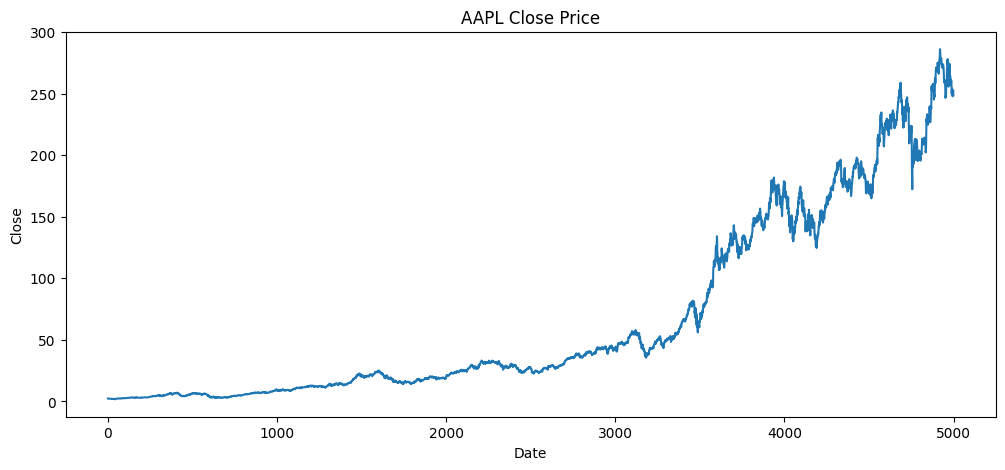

In [12]:
one['close'].plot(figsize=(12, 5), title=f'{ticker} Close Price')
plt.xlabel('Date')
plt.ylabel('Close')
plt.show()

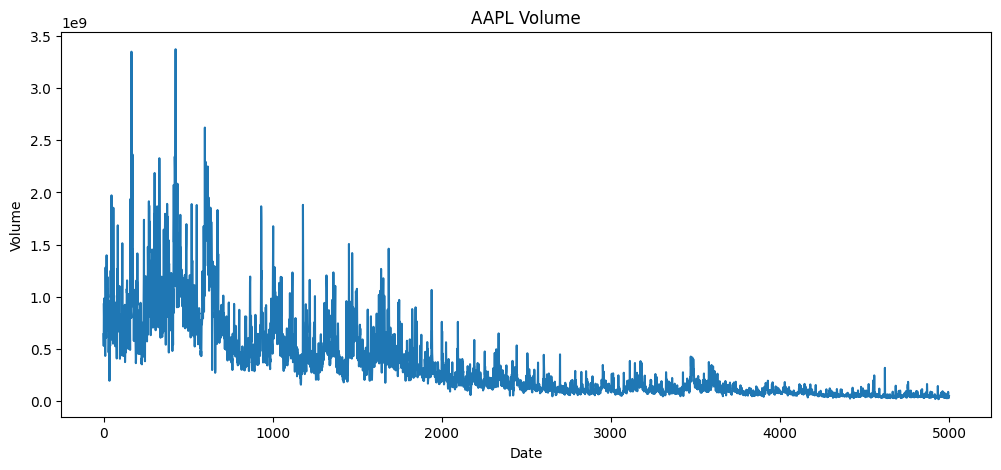

In [13]:
one['volume'].plot(figsize=(12, 5), title=f'{ticker} Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

## Compare closing prices across tickers

This uses the most recent 252 trading days (roughly one trading year).

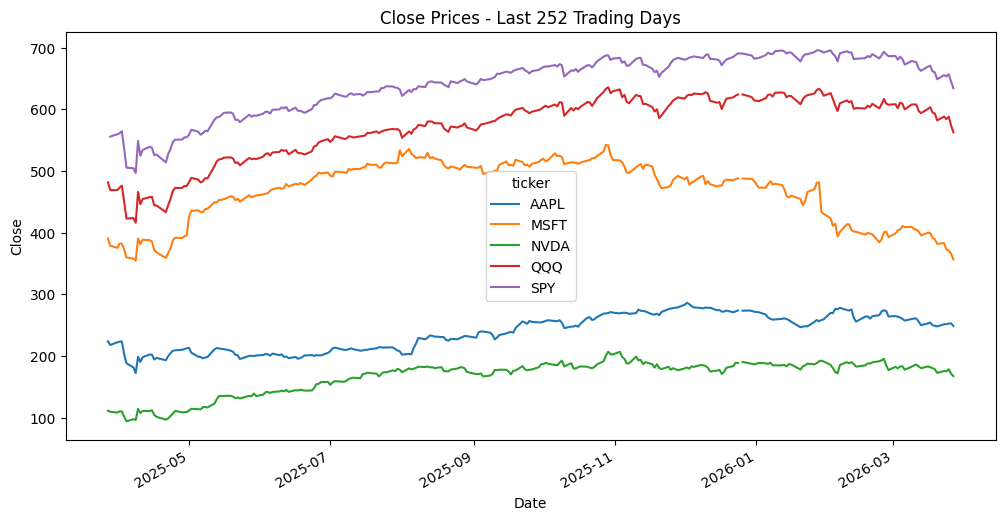

In [14]:
latest_window = (
    df.sort_values('date')
      .groupby('ticker', group_keys=False)
      .tail(252)
)

pivot_close = latest_window.pivot(index='date', columns='ticker', values='close')
pivot_close.plot(figsize=(12, 6), title='Close Prices - Last 252 Trading Days')
plt.xlabel('Date')
plt.ylabel('Close')
plt.show()

## Quick sanity metrics

In [15]:
summary = {
    'rows': len(df),
    'tickers': int(df['ticker'].nunique()),
    'min_date': df['date'].min(),
    'max_date': df['date'].max(),
    'duplicate_rows': int(df.duplicated(['date', 'ticker']).sum()),
    'total_nulls': int(df.isnull().sum().sum()),
}
summary

{'rows': 25000,
 'tickers': 5,
 'min_date': Timestamp('2006-05-12 00:00:00'),
 'max_date': Timestamp('2026-03-27 00:00:00'),
 'duplicate_rows': 0,
 'total_nulls': 0}

## Suggested interpretation

If this notebook looks good, you should expect:
- zero duplicate `(date, ticker)` rows
- zero negative prices
- zero negative volume
- sensible row counts for each ticker
- time series plots that look smooth and realistic

Once those checks pass, the next step is feature engineering.